In [2]:
from CosinorPy import file_parser, cosinor, cosinor1
import numpy as np
import pandas as pd
import os

## Generate test data

In [3]:
df = file_parser.generate_test_data(phase = 0, n_components = 1, name="test1", noise=0.5, replicates = 3)
df2 = file_parser.generate_test_data(phase = np.pi, n_components = 1, name="test2", noise=0.5, replicates = 3)
df = df.append(df2, ignore_index=True)

df2 = file_parser.generate_test_data(phase = 0, n_components = 3, name="test3", noise=0.5, replicates = 3, time_step=1)
df = df.append(df2, ignore_index=True)
df2 = file_parser.generate_test_data(phase = np.pi, n_components = 3, name="test4", noise=0.5, replicates = 3, time_step=1)
df = df.append(df2, ignore_index=True)

C:\Users\Tassara\AppData\Local\Temp/ipykernel_2948/959025309.py:3: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(df2, ignore_index=True)
C:\Users\Tassara\AppData\Local\Temp/ipykernel_2948/959025309.py:6: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(df2, ignore_index=True)
C:\Users\Tassara\AppData\Local\Temp/ipykernel_2948/959025309.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(df2, ignore_index=True)


These data can be exported to either excel or csv format

In [4]:
#file_parser.export(df,os.path.join("test_data","independent_data.xlsx"))

In [5]:
#file_parser.export_csv(df,os.path.join("test_data","independent_data.csv"))

In [6]:
df = file_parser.read_excel(os.path.join("test_data","data.xlsx"))

FileNotFoundError: [Errno 2] No such file or directory: 'test_data\\data.xlsx'

## Cosinor analysis

Identify the best models and/or the best periods (possible periods can be given as an interval or as a single value).

In [7]:
df_results = cosinor.fit_group(df, n_components = [1,2,3], period=24, plot=False) #folder=""

Get the best fitting periods with criterium 'RSS' (```reverse=False``` means lower is better)

In [8]:
df_best_fits = cosinor.get_best_fits(df_results, n_components = [1,2,3], criterium='RSS', reverse = False)
df_best_fits

,test,period,n_components,p,q,p_reject,q_reject,RSS,R2,R2_adj,log-likelihood,amplitude,acrophase,mesor,peaks,heights,troughs,heights2,ME,resid_SE
0,test1,24.0,1.0,1.110223e-16,1.211152e-16,1.648077e-01,2.472115e-01,15.530322,0.705670,0.697494,-47.369375,0.978611,-0.006289,0.007946,[],[],[12.012012012012011],[-0.9706650130927809],0.925832,0.464434
1,test1,24.0,2.0,1.110223e-16,1.211152e-16,1.050666e-01,1.801142e-01,15.318521,0.709684,0.693094,-46.854433,0.979083,-0.075474,0.063025,[0.2882882882882883],[1.0420999565359734],[11.531531531531531],[-0.9160584097669797],0.932996,0.467799
2,test1,24.0,3.0,1.110223e-16,1.211152e-16,5.853361e-02,1.422801e-01,15.075906,0.714282,0.689071,-46.255754,0.956186,0.094342,0.039334,[23.63963963963964],[0.9955171350009066],[10.474474474474475],[-0.9168317941630406],0.939577,0.470855
3,test2,24.0,1.0,1.110223e-16,1.211152e-16,5.269072e-01,7.025429e-01,17.049322,0.662723,0.653354,-50.868726,0.928311,3.100711,0.097007,[12.156156156156156],[1.025316211339632],[0.1921921921921922],[-0.8312864683484368],0.970053,0.486617
4,test2,24.0,2.0,1.110223e-16,1.211152e-16,6.595944e-01,7.915133e-01,16.297439,0.677597,0.659174,-49.177385,0.953297,2.786237,0.032571,[13.357357357357357],[0.9858676528393532],[23.44744744744745],[-0.9207141787171774],0.962345,0.482515
5,test2,24.0,3.0,1.221245e-15,1.221245e-15,8.582179e-01,8.582179e-01,15.557836,0.692228,0.665072,-47.435753,1.044355,3.138448,0.003865,[12.012012012012011],[1.0482203091806876],[23.303303303303302],[-1.040490214663663],0.954476,0.478322
6,test3,24.0,1.0,1.110223e-16,1.211152e-16,1.110223e-16,1.332268e-15,64.010997,0.516363,0.509646,-147.477704,0.955205,0.106921,0.048641,[23.59159159159159],[1.003838784493517],[11.57957957957958],[-0.9065640346171452],1.317830,0.666724
7,test3,24.0,2.0,1.110223e-16,1.211152e-16,2.515363e-07,1.006145e-06,40.960481,0.690522,0.681804,-114.663836,1.131844,0.094342,0.395058,[23.63963963963964],[1.5269016143024963],"[7.303303303303303, 16.0]","[-0.7367856849773167, -0.6904549789552894]",1.061704,0.537079
8,test3,24.0,3.0,1.110223e-16,1.211152e-16,8.710607e-02,1.742121e-01,29.758393,0.775160,0.765524,-91.180843,1.304498,-0.006289,0.546907,[],[],"[5.573573573573573, 12.636636636636636, 18.066...","[-0.7334931050670457, -0.7575911975006635, -0....",0.911505,0.461042
9,test4,24.0,1.0,1.110223e-16,1.211152e-16,6.242910e-09,3.745746e-08,59.771224,0.590195,0.584503,-142.440708,1.071789,-3.107001,0.000137,[11.867867867867869],[1.0719228568035488],[23.87987987987988],[-1.0716518946549263],1.273439,0.644265


or get the best models (the best fitting periods and the best fitting models - in dependence on the number of components; by default the criterium is p-value)

In [9]:
df_best_models = cosinor.get_best_models(df, df_results, n_components = [1,2,3])

... and plot these models (together with qq-plots and phase diagrams).

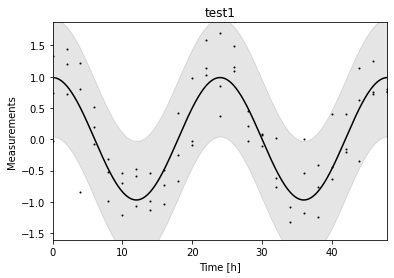

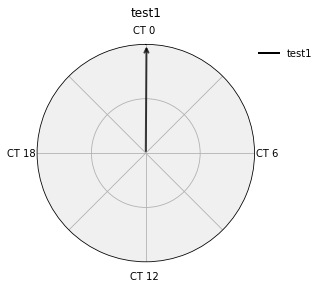

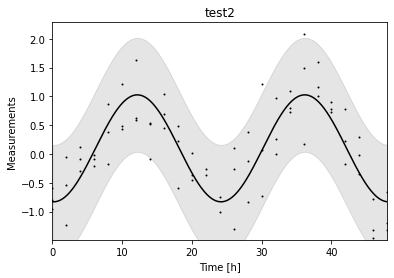

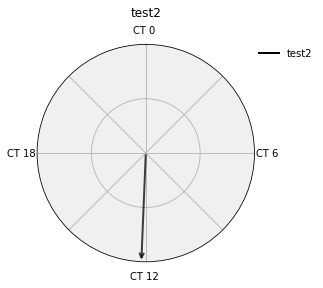

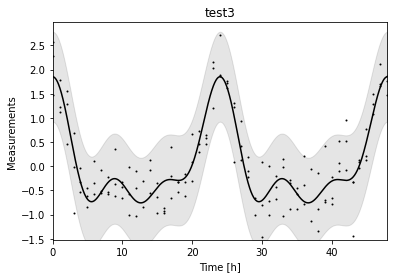

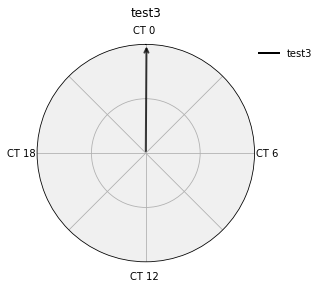

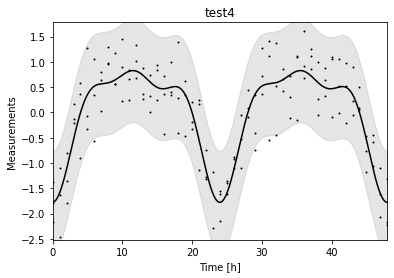

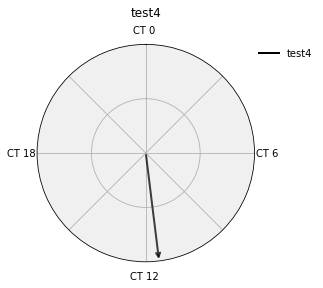

In [10]:
cosinor.plot_df_models(df, df_best_models)

Display the results or store the results as a csv file:

In [11]:
df_best_models

,test,period,n_components,p,q,p_reject,q_reject,RSS,R2,R2_adj,log-likelihood,amplitude,acrophase,mesor,peaks,heights,troughs,heights2,ME,resid_SE
0,test1,24.0,1.0,1.110223e-16,1.211152e-16,0.164808,0.247212,15.530322,0.705670,0.697494,-47.369375,0.978611,-0.006289,0.007946,[],[],[12.012012012012011],[-0.9706650130927809],0.925832,0.464434
1,test2,24.0,1.0,1.110223e-16,1.211152e-16,0.526907,0.702543,17.049322,0.662723,0.653354,-50.868726,0.928311,3.100711,0.097007,[12.156156156156156],[1.025316211339632],[0.1921921921921922],[-0.8312864683484368],0.970053,0.486617
2,test3,24.0,3.0,1.110223e-16,1.211152e-16,0.087106,0.174212,29.758393,0.775160,0.765524,-91.180843,1.304498,-0.006289,0.546907,[],[],"[5.573573573573573, 12.636636636636636, 18.066...","[-0.7334931050670457, -0.7575911975006635, -0....",0.911505,0.461042
3,test4,24.0,3.0,1.110223e-16,1.211152e-16,0.776718,0.847329,35.652168,0.755561,0.745085,-104.462200,1.303055,-3.018948,-0.475373,"[11.531531531531531, 17.585585585585587]","[0.8276824216191028, 0.5113930536810009]",[23.975975975975977],[-1.7784281201911853],0.997694,0.504637


### Extended analyses using a multi-component cosinor model
Analyse the best models with sampling of confidence intervals of regression coefficients.

In [12]:
df_results_extended = cosinor.analyse_best_models(df, df_best_models, analysis="CI")
df_results_extended

c:\Users\Tassara\AppData\Local\Programs\Python\Python38\lib\site-packages\skopt\space\space.py:116: UserWarning: Dimension array([-0.09912405,  0.11501744]) was inferred to Real(low=-0.09912405146023828, high=0.11501744224032862, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(-0.09912405146023828, 0.11501744224032862), prior=None). See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
c:\Users\Tassara\AppData\Local\Programs\Python\Python38\lib\site-packages\skopt\space\space.py:116: UserWarning: Dimension array([-0.15203663,  0.15657411]) was inferred to Real(low=-0.15203662948959198, high=0.15657410886442732, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(-0.15203662948959198, 0.15657410886442732), prior=None). See the documentation of the check_dimension function for the upcoming API.
 

,test,period,n_components,p,q,p_reject,q_reject,amplitude,CI(amplitude),p(amplitude),q(amplitude),acrophase,CI(acrophase),p(acrophase),q(acrophase),mesor,CI(mesor),p(mesor),q(mesor)
0,test1,24.0,1.0,1.110223e-16,1.211152e-16,0.164808,0.247212,0.978611,"[0.8200696482815535, 1.1371514730182233]",0.0,0.0,-0.006289,"[-0.18868424345884627, 0.17610529389492413]",0.945387,0.945387,0.007946,"[-0.09904067413070994, 0.11493176924492499]",8.827183e-01,0.882718
1,test2,24.0,1.0,1.110223e-16,1.211152e-16,0.526907,0.702543,0.928311,"[0.7577876592950514, 1.0988333811963544]",0.0,0.0,3.100711,"[2.8868689249203503, 3.314553210093736]",0.000000,0.000000,0.097007,"[-0.015166506375935418, 0.20917954192852628]",8.901118e-02,0.118682
2,test3,24.0,3.0,1.110223e-16,1.211152e-16,0.087106,0.174212,1.304498,"[1.0568573068699978, 1.5521389781824122]",0.0,0.0,-0.006289,"[-0.10692107129334527, 0.09434212172942313]",0.901836,0.945387,0.546907,"[0.33812301885009965, 0.7556908712009833]",7.616148e-07,0.000003
3,test4,24.0,3.0,1.110223e-16,1.211152e-16,0.776718,0.847329,1.303055,"[1.0588848430939721, 1.5472256987163162]",0.0,0.0,-3.018948,"[-4.754842935162929, -1.2830528555201566]",0.000771,0.001542,-0.475373,"[-0.6876611794805214, -0.26308451909156094]",1.907818e-05,0.000038


Or using bootstrap:

In [13]:
df_results_extended = cosinor.analyse_best_models(df, df_best_models, analysis="bootstrap")
df_results_extended

,test,period,n_components,p,q,p_reject,q_reject,amplitude,CI(amplitude),p(amplitude),q(amplitude),acrophase,CI(acrophase),p(acrophase),q(acrophase),mesor,CI(mesor),p(mesor),q(mesor)
0,test1,24.0,1.0,1.110223e-16,1.211152e-16,0.164808,0.247212,0.978611,"[0.8396463198032661, 1.1309038766984094]",0.0,0.0,-0.006289,"[-0.1544225714150325, 0.1493879521573507]",9.740645e-01,9.740645e-01,0.007946,"[-0.09321026298960979, 0.10819145343431179]",8.839759e-01,8.839759e-01
1,test2,24.0,1.0,1.110223e-16,1.211152e-16,0.526907,0.702543,0.928311,"[0.7713284436740592, 1.090366379037647]",0.0,0.0,3.100711,"[2.930644079504777, 3.2564723309861545]",0.000000e+00,0.000000e+00,0.097007,"[-0.019315492599990172, 0.20627960852965443]",1.041990e-01,1.389320e-01
2,test3,24.0,3.0,1.110223e-16,1.211152e-16,0.087106,0.174212,1.304498,"[1.2030294342464738, 1.4688756818516788]",0.0,0.0,-0.006289,"[-0.06492653771844684, 0.06121420614105713]",9.539576e-01,9.740645e-01,0.546907,"[0.4086900313846923, 0.6345466529788385]",0.000000e+00,0.000000e+00
3,test4,24.0,3.0,1.110223e-16,1.211152e-16,0.776718,0.847329,1.303055,"[1.1901016019526025, 1.449315494986999]",0.0,0.0,-3.018948,"[-3.731533653373113, -2.1639968603317956]",3.330669e-13,6.661338e-13,-0.475373,"[-0.5948623927999684, -0.3458443505700435]",2.637890e-13,5.275780e-13


## Cosinor1 analysis

Only 1-component model can be used, but statistics is different in the background...

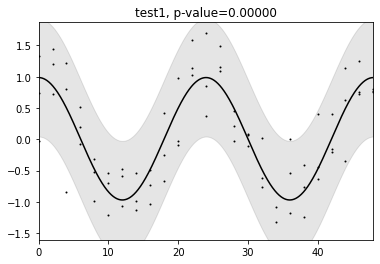

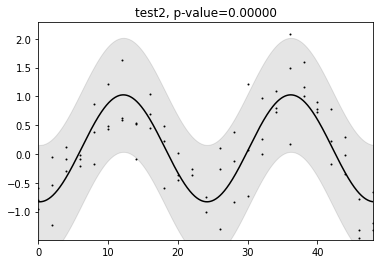

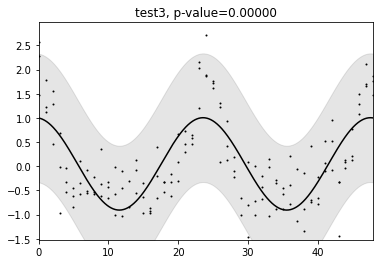

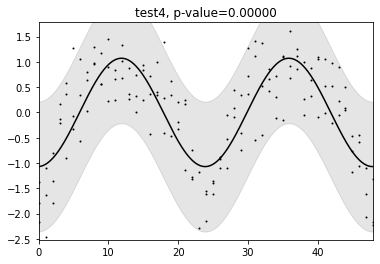

In [14]:
df_results = cosinor1.fit_group(df, period=[24])

In [15]:
df_results

,test,period,p,q,amplitude,p(amplitude),q(amplitude),CI(amplitude),acrophase,p(acrophase),q(acrophase),CI(acrophase),acrophase[h]
0,test1,24.0,7.551847e-20,1.006913e-19,0.978612,1.978128e-39,3.956256e-39,"[0.8326267711392983, 1.1245973141751118]",-0.002318,9.766175e-01,9.766175e-01,"[-0.15734634017100743, 0.15270968821742334]",0.008855
1,test2,24.0,1.017492e-17,1.017492e-17,0.928313,1.268221e-32,1.268221e-32,"[0.7753426664290086, 1.0812825695427786]",3.097425,2.340478e-275,4.680955e-275,"[2.9262031495960676, 3.2686463318255217]",12.168709
2,test3,24.0,1.929185e-23,3.858370e-23,0.955206,2.637972e-35,3.517296e-35,"[0.8042153906949873, 1.1061965697258704]",0.111158,1.764904e-01,2.353205e-01,"[-0.050027946038150056, 0.2723431122747053]",23.575409
3,test4,24.0,1.275124e-28,5.100496e-28,1.071791,5.106103e-47,2.042441e-46,"[0.9259204189882064, 1.2176618277381683]",-3.110699,0.000000e+00,0.000000e+00,"[-3.249543554807115, -2.971854740081225]",11.881995


## Comparison analysis

Define the pairs to compare

In [16]:
pairs = (["test1", "test2"],["test3", "test4"])

### Comparison using cosinor1


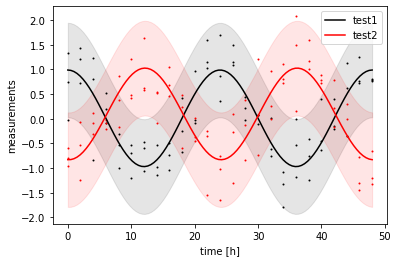

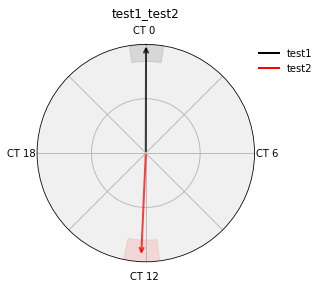

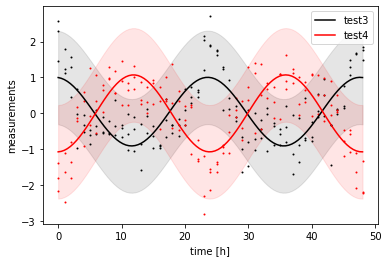

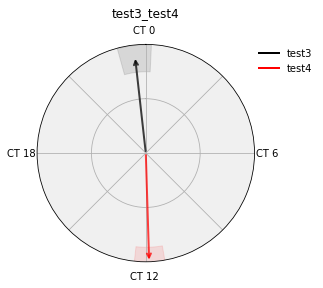

In [17]:
#compare_cosinor1 = cosinor1.test_cosinor_pairs(df, pairs, period=24, folder='paper' )
compare_cosinor1 = cosinor1.test_cosinor_pairs(df, pairs, period=24)

In [18]:
compare_cosinor1[["test", "q(d_amplitude)", "q(d_acrophase)"]]

,test,q(d_amplitude),q(d_acrophase)
0,test1 vs. test2,0.641049,7.581343e-153
1,test3 vs. test4,0.552834,2.205124e-175


### Comparison using a multi-component cosinor model

Use an 1-component cosinor for the first pair

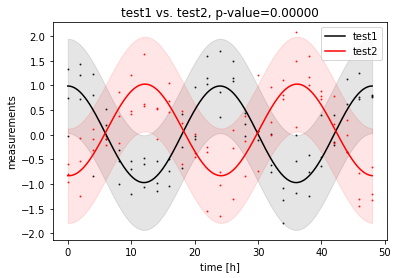

In [19]:
df_cosinor_lm1 = cosinor.compare_pairs_limo(df, pairs[:1], n_components = 1, period = 24)#, folder = 'results\\test_limo_tester\\')

In [20]:
df_cosinor_lm1

,test,period,n_components,p,q,p params,q params,p(F test),q(F test),d_amplitude,d_acrophase
0,test1 vs. test2,24,1,2.195094e-34,2.195094e-34,7.067063e-38,7.067063e-38,1.110223e-16,1.110223e-16,-0.0503,3.107001


Use a 3-component cosinor for second pair

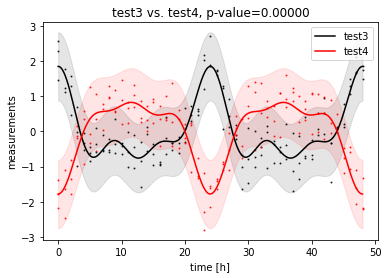

In [21]:
df_cosinor_lm2 = cosinor.compare_pairs_limo(df, pairs[1:], n_components = 3, period = 24)#, folder = 'results\\test_limo_tester\\')

In [22]:
df_cosinor_lm2

,test,period,n_components,p,q,p params,q params,p(F test),q(F test),d_amplitude,d_acrophase
0,test3 vs. test4,24,3,4.128478e-80,4.128478e-80,2.186521e-72,2.186521e-72,1.110223e-16,1.110223e-16,-0.001443,-3.012658


### Extended analyses using a multi-component cosinor model

To get more informative results we can use an extended comparison using bootstrapping or sampling of regression coefficients confidence intervals.

#### This can be performed on the basis of the best models for each test...

You can do the analysis with the sampling of confidence intervals:

In [23]:
df_cosinor_lm = cosinor.compare_pairs_best_models(df, df_best_models, pairs, analysis="CI")
df_cosinor_lm

c:\Users\Tassara\AppData\Local\Programs\Python\Python38\lib\site-packages\skopt\space\space.py:116: UserWarning: Dimension array([-0.09912405,  0.11501744]) was inferred to Real(low=-0.09912405146023828, high=0.11501744224032862, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(-0.09912405146023828, 0.11501744224032862), prior=None). See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
c:\Users\Tassara\AppData\Local\Programs\Python\Python38\lib\site-packages\skopt\space\space.py:116: UserWarning: Dimension array([-0.15203663,  0.15657411]) was inferred to Real(low=-0.15203662948959198, high=0.15657410886442732, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(-0.15203662948959198, 0.15657410886442732), prior=None). See the documentation of the check_dimension function for the upcoming API.
 

,test,period1,n_components1,period2,n_components2,p1,p2,q1,q2,d_amplitude,...,p(d_amplitude),q(d_amplitude),d_acrophase,CI(d_acrophase),p(d_acrophase),q(d_acrophase),d_mesor,CI(d_mesor),p(d_mesor),q(d_mesor)
0,test1 vs. test2,24.0,1.0,24.0,1.0,1.110223e-16,1.110223e-16,1.110223e-16,1.110223e-16,-0.050300,...,0.668611,0.993223,3.107001,"[2.820436376810165, 3.3935647077678435]",0.000000,0.000000,0.089061,"[-0.06676436844162173, 0.24488630887999754]",2.604815e-01,2.604815e-01
1,test3 vs. test4,24.0,3.0,24.0,3.0,1.110223e-16,1.110223e-16,1.110223e-16,1.110223e-16,-0.001443,...,0.993223,0.993223,-3.012658,"[-4.416786423414628, -1.608530417704536]",0.000033,0.000033,-1.022280,"[-1.3519147692506326, -0.6926448193725327]",3.424906e-09,6.849812e-09


Or using bootstrap:

In [24]:
df_cosinor_lm = cosinor.compare_pairs_best_models(df, df_best_models, pairs, analysis="bootstrap")
df_cosinor_lm

,test,period1,n_components1,period2,n_components2,p1,p2,q1,q2,d_amplitude,...,p(d_amplitude),q(d_amplitude),d_acrophase,CI(d_acrophase),p(d_acrophase),q(d_acrophase),d_mesor,CI(d_mesor),p(d_mesor),q(d_mesor)
0,test1 vs. test2,24.0,1.0,24.0,1.0,1.110223e-16,1.110223e-16,1.110223e-16,1.110223e-16,-0.050300,...,0.643918,0.988156,3.107001,"[2.884038142469883, 3.3299629421081254]",0.000000e+00,0.000000e+00,0.089061,"[-0.05783773352174304, 0.23595967396011885]",0.234582,0.234582
1,test3 vs. test4,24.0,3.0,24.0,3.0,1.110223e-16,1.110223e-16,1.110223e-16,1.110223e-16,-0.001443,...,0.988156,0.988156,-3.012658,"[-3.822239327836087, -2.203077513283077]",4.203304e-13,4.203304e-13,-1.022280,"[-1.1895160629190906, -0.8550435257040747]",0.000000,0.000000


#### You can also choose to use the same type of a cosinor model for each comparison (namely, the same number of components and period)

Using sampling of confidence intervals...

In [25]:
df_cosinor_lm = cosinor.compare_pairs(df, pairs, n_components = 1, period=24, analysis="CI")

c:\Users\Tassara\AppData\Local\Programs\Python\Python38\lib\site-packages\skopt\space\space.py:116: UserWarning: Dimension array([-0.09912405,  0.11501744]) was inferred to Real(low=-0.09912405146023828, high=0.11501744224032862, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(-0.09912405146023828, 0.11501744224032862), prior=None). See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
c:\Users\Tassara\AppData\Local\Programs\Python\Python38\lib\site-packages\skopt\space\space.py:116: UserWarning: Dimension array([-0.15203663,  0.15657411]) was inferred to Real(low=-0.15203662948959198, high=0.15657410886442732, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(-0.15203662948959198, 0.15657410886442732), prior=None). See the documentation of the check_dimension function for the upcoming API.
 

In [26]:
df_cosinor_lm

,test,period,n_components,p1,p2,q1,q2,d_amplitude,CI(d_amplitude),p(d_amplitude),q(d_amplitude),d_acrophase,CI(d_acrophase),p(d_acrophase),q(d_acrophase),d_mesor,CI(d_mesor),p(d_mesor),q(d_mesor)
0,test1 vs. test2,24,1,1.110223e-16,1.110223e-16,1.110223e-16,1.110223e-16,-0.050300,"[-0.2836152590792843, 0.1830151782709134]",0.670652,0.670652,3.107001,"[2.828637745558576, 3.3853633390194324]",0.0,0.0,0.089061,"[-0.06657079240913252, 0.24469273284750834]",0.259892,0.519783
1,test3 vs. test4,24,1,1.110223e-16,1.110223e-16,1.110223e-16,1.110223e-16,0.116585,"[-0.11711208078927843, 0.3502811876660323]",0.326975,0.653950,3.069264,"[2.818746205979509, 3.3197811812149602]",0.0,0.0,-0.048503,"[-0.20004241006689963, 0.1030357968680913]",0.529210,0.529210


... or bootstrap

In [27]:
df_cosinor_lm = cosinor.compare_pairs(df, pairs, n_components = 1, period=24, analysis="bootstrap")

In [28]:
df_cosinor_lm

,test,period,n_components,p1,p2,q1,q2,d_amplitude,CI(d_amplitude),p(d_amplitude),q(d_amplitude),d_acrophase,CI(d_acrophase),p(d_acrophase),q(d_acrophase),d_mesor,CI(d_mesor),p(d_mesor),q(d_mesor)
0,test1 vs. test2,24,1,1.110223e-16,1.110223e-16,1.110223e-16,1.110223e-16,-0.050300,"[-0.26717379812988507, 0.16657371732151416]",0.649263,0.649263,3.107001,"[2.8805838896419194, 3.333417194936089]",0.0,0.0,0.089061,"[-0.0588523425553836, 0.23697428299375942]",0.237806,0.475612
1,test3 vs. test4,24,1,1.110223e-16,1.110223e-16,1.110223e-16,1.110223e-16,0.116585,"[-0.09414584297804743, 0.32731494985480125]",0.278057,0.556115,3.069264,"[2.854106324915488, 3.284421062278981]",0.0,0.0,-0.048503,"[-0.19758934795122826, 0.10058273475241994]",0.523523,0.523523
